# [Computational Social Science] Project 4: Unsupervised Learning

**Enter your Name:** Ishika Sachdeva

*Semester:* Fall 2025

## Data Description and Preprocessing

For this project, you will explore data from the [National Health and Nutrition Examination Survey](https://www.kaggle.com/cdc/national-health-and-nutrition-examination-survey?select=questionnaire.csv). NHANES is a unique study that combines survey methodology with in-person medical examinations to create a dataset with demographic information, health indicators, and health outcomes.

We start by importing the data and doing some preliminary preprocessing for you. We import some libraries that will be helpful as well. 'SEQN' is the ID number for each respondent, and 'HSD010' will be our target outcome. [HSD010](https://wwwn.cdc.gov/Nchs/Nhanes/2013-2014/HSQ_H.htm#HSD010) asks for the respondent's self reported health condition, which can range from "excellent" to "poor."

In [13]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# from keras.models import Sequential
# from keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
sns.set_style("darkgrid")
from sklearn.model_selection import train_test_split

In [14]:
# Load nhanes data
nhanes = pd.read_csv('nhanes.csv')
# Get the ID numbers for each observation (seqn)
seqn = nhanes['SEQN']
# Get the target, "self-reported health condition," HSD010
hsd010 = nhanes['HSD010']
# Drop SEQN from the dataframe and then apply the standard scaler
nhanes = nhanes.drop(['SEQN', 'HSD010'], axis = 1)
nhanes_scaled = pd.DataFrame(StandardScaler().fit_transform(nhanes),
                             columns = nhanes.columns)
# Add the ID and target back in
nhanes_scaled['SEQN'] = seqn
nhanes_scaled['HSD010'] = hsd010
nhanes_scaled = nhanes_scaled.set_index('SEQN')
nhanes_scaled.head()

,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1MNRSP,DR1HELPD,DBQ095Z,...,OHQ770,OHQ845,PAAQUEX,SMQ860,SMQ870,SMQ872,SMQ874,SMQ878,SMAQUEX.x,HSD010
SEQN,,,,,,,,,,,,,,,,,,,,,
73568,0.0,2.034312,0.0,0.324834,-0.393906,1.085853,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-0.646584,-0.484200,1.125008,0.0,-2.081666,1.087115,1.463404,0.612440,1
73576,0.0,0.261930,0.0,-3.078499,0.568251,0.634362,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-1.539259,-0.484200,1.125008,0.0,-2.081666,1.087115,-0.683338,-1.632812,1
73579,0.0,0.728346,0.0,0.324834,1.530407,-1.623092,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-1.539259,2.065262,-0.888883,0.0,0.480384,-0.919866,-0.683338,-1.632812,2
73581,0.0,-0.857470,0.0,0.324834,0.480782,1.085853,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-0.646584,-0.484200,1.125008,0.0,0.480384,-0.919866,-0.683338,0.612440,2
73584,0.0,0.495138,0.0,0.324834,0.305844,-1.623092,-0.194202,-0.057306,0.128246,0.080373,...,-2.605509,0.246091,2.065262,1.125008,0.0,0.480384,-0.919866,1.463404,-1.632812,3


## Plots

Let's take a look at the data. Below we visualize boxplots of family income to federal poverty line ratio ('INDFMPIR') and self-reported health condition. Notice how there are some clear patterns (the lower the ratio, the lower reported health condition), but it's not a perfect separation. We have 240+ features in our dataset, and we likely have several features in our dataset that highly correlate with our family income-poverty line ratio measure - PCA will help us simplify these.

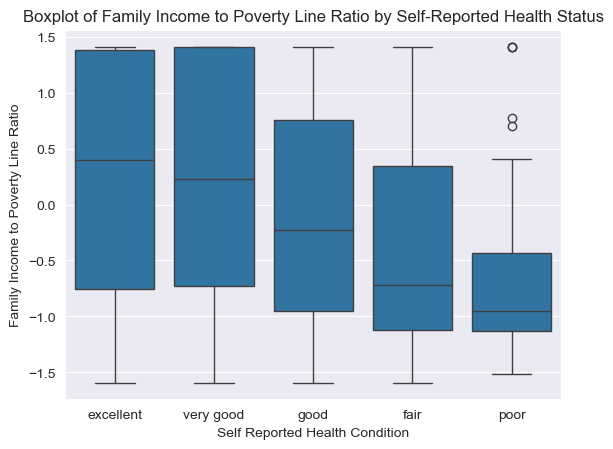

In [15]:
# Create a binary version of hsd010 where 1-3 are "good" and 4-5 are "poor"
nhanes_scaled['HSD010_binary'] = hsd010_binary = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['good', 'good', 'good', 'poor', 'poor']) 
# Recode the original hsd010 with the string labels
nhanes_scaled['HSD010'] = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['excellent', 'very good', 'good', 'fair', 'poor'])
# Boxplot of hsd010
ax = sns.boxplot(x = 'HSD010', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Self-Reported Health Status")
plt.show()

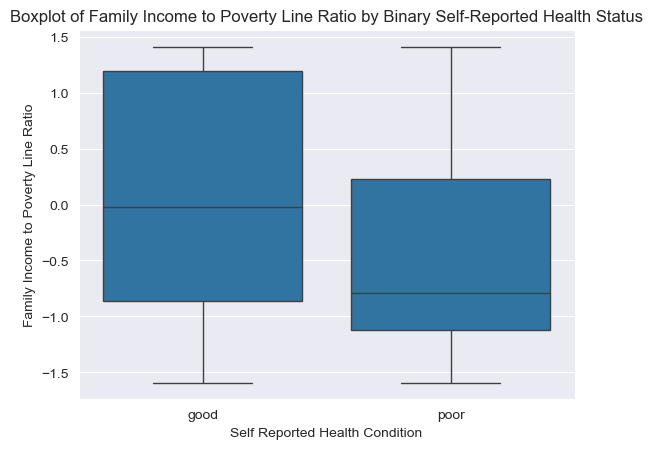

In [16]:
# Boxplot of hsd010_binary
ax = sns.boxplot(x = 'HSD010_binary', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Binary Self-Reported Health Status")
plt.show()

Family income also is not necessarily well correlated with measured health outcomes. See below where we look at the relationship between Body Mass Index (BMI) and the family income-poverty line ratio, and shade points by self-reported health condition. It's hard to find a clear pattern - this is where clustering may come in handy. 

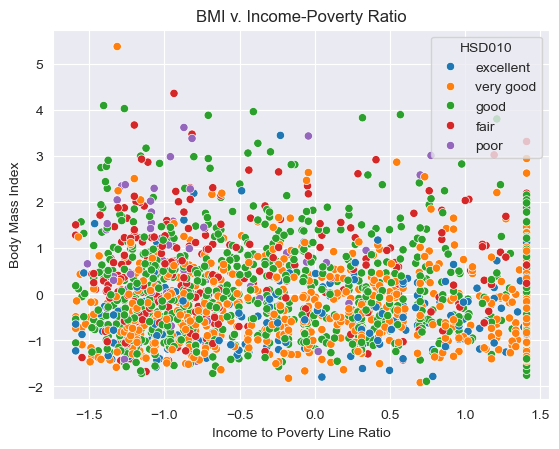

In [17]:
ax = sns.scatterplot(x = "INDFMPIR", y = "BMXBMI", hue = "HSD010", palette = "tab10", data = nhanes_scaled)
ax.set(xlabel = "Income to Poverty Line Ratio",
      ylabel = "Body Mass Index")
ax.set_title("BMI v. Income-Poverty Ratio")
plt.show()

Before we move to working on unsupervised methods, we'll drop our target variables again:

In [18]:
nhanes_scaled = nhanes_scaled.drop(['HSD010', 'HSD010_binary'], axis = 1)

In [19]:
nhanes_scaled

,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1MNRSP,DR1HELPD,DBQ095Z,...,OHQ033,OHQ770,OHQ845,PAAQUEX,SMQ860,SMQ870,SMQ872,SMQ874,SMQ878,SMAQUEX.x
SEQN,,,,,,,,,,,,,,,,,,,,,
73568,0.0,2.034312,0.0,0.324834,-0.393906,1.085853,-0.194202,-0.057306,0.128246,-0.189513,...,-0.680203,0.383802,-0.646584,-0.484200,1.125008,0.0,-2.081666,1.087115,1.463404,0.612440
73576,0.0,0.261930,0.0,-3.078499,0.568251,0.634362,-0.194202,-0.057306,0.128246,0.080373,...,-0.680203,0.383802,-1.539259,-0.484200,1.125008,0.0,-2.081666,1.087115,-0.683338,-1.632812
73579,0.0,0.728346,0.0,0.324834,1.530407,-1.623092,-0.194202,-0.057306,0.128246,-0.189513,...,-0.680203,0.383802,-1.539259,2.065262,-0.888883,0.0,0.480384,-0.919866,-0.683338,-1.632812
73581,0.0,-0.857470,0.0,0.324834,0.480782,1.085853,-0.194202,-0.057306,0.128246,0.080373,...,-0.680203,0.383802,-0.646584,-0.484200,1.125008,0.0,0.480384,-0.919866,-0.683338,0.612440
73584,0.0,0.495138,0.0,0.324834,0.305844,-1.623092,-0.194202,-0.057306,0.128246,0.080373,...,-0.680203,-2.605509,0.246091,2.065262,1.125008,0.0,0.480384,-0.919866,1.463404,-1.632812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83694,0.0,0.261930,0.0,0.324834,-0.481375,1.085853,-0.194202,-0.057306,0.128246,-0.189513,...,0.998146,0.383802,-0.646584,-0.484200,1.125008,0.0,0.480384,1.087115,-0.683338,0.612440
83696,0.0,0.495138,0.0,0.324834,1.093063,0.634362,-0.194202,-0.057306,0.128246,-0.189513,...,0.998146,0.383802,0.246091,-0.484200,1.125008,0.0,-2.081666,1.087115,-0.683338,-1.632812
83704,0.0,0.728346,0.0,-3.078499,0.305844,-0.268620,-0.194202,-0.057306,0.128246,0.080373,...,-0.680203,0.383802,2.031441,2.065262,1.125008,0.0,0.480384,-0.919866,-0.683338,-1.632812


## Principal Component Analysis

Conduct a Principal Component Analysis (PCA) of the nhanes data. The data has already been prepared for you, so you can work directly on nhanes_scaled. Be sure to do the following:

- Choose the number of components and provide 1-2 sentences about your choice of the number of components. 
- Plot a barplot of the variation explained by each component. *Hint*: look at the attributes associated with your model. 
- Choose how many components you will use to fit a supervised learning model and provide 1-2 sentences to explain that choice.
- Plot a 2D scatterplot of the first two components and provide 1-2 sentences analyzing the plot.

### Train PCA and Discuss Number of Components

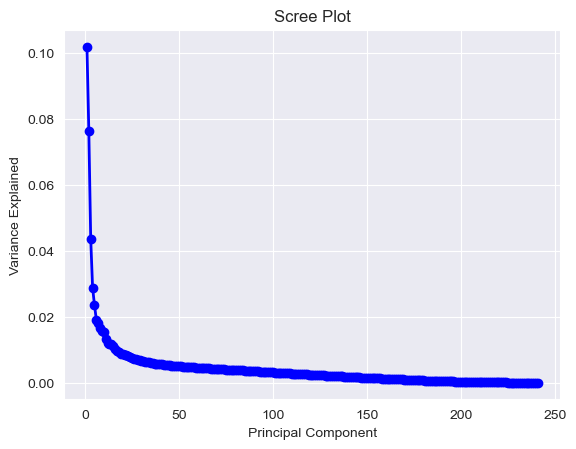

In [21]:
# scale the data
# the data is already scaled with nhanes_scaled, but otherwise this is where I would use Scaler()

#defining X as nhanes_scaled that was defined above 

X= nhanes_scaled

# skree plot to select # of components to fit the model

# fit PCA
# ----------
pca_all = PCA() # not specifying the number of components if we want to keep them all
principalComponents_nhanes = pca_all.fit_transform(X)


# create scree plot from PCA fit
# ----------
PC_values = np.arange(pca_all.n_components_) + 1
plt.plot(PC_values, pca_all.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()



### Barplot of Components

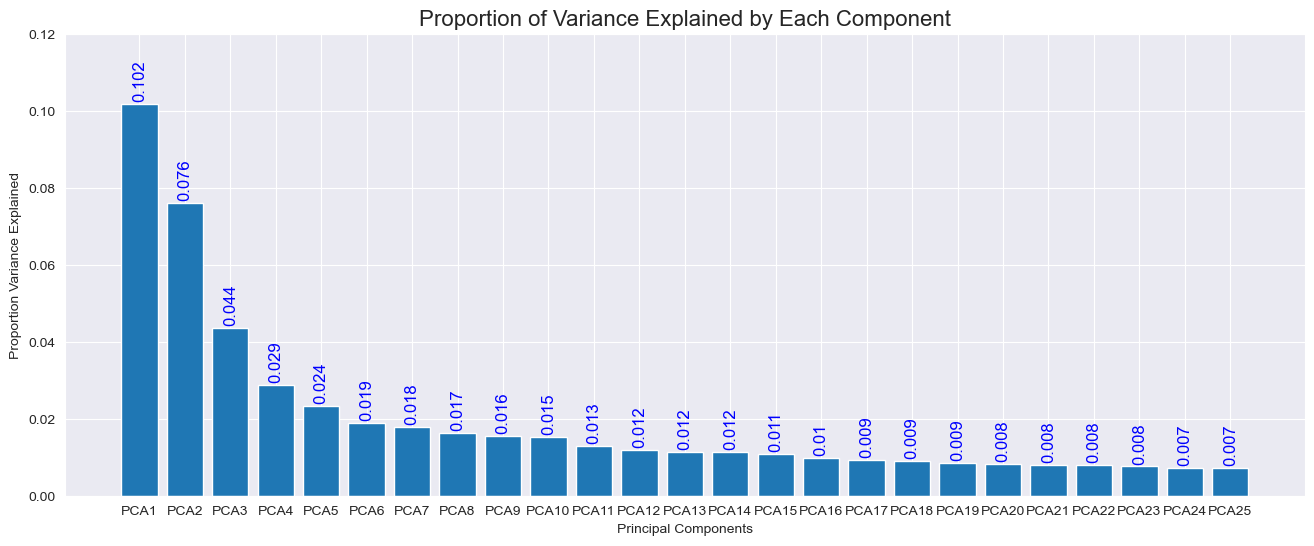

In [22]:
#train the model with the 25 components that we got from skree plot above

pca = PCA(n_components=25)
principalComponents_nhanes = pca.fit_transform(nhanes_scaled)

# create data frame 
pca_columns = [f"PCA{x+1}" for x in np.arange(0, principalComponents_nhanes.shape[1])]
pca_df = pd.DataFrame(principalComponents_nhanes, columns=pca_columns)

# look at the explained variances from nhanes PCAs on health status 
pca.explained_variance_ratio_

# create barplot of components based on the variances above 
gig, ax = plt.subplots(1, 1, figsize=(16, 6))
p = ax.bar(pca_columns, pca.explained_variance_ratio_)
ax.bar_label(p,
             label_type='edge', labels=[round(var_exp, 3) for var_exp in pca.explained_variance_ratio_],
             c="blue",
             fontsize=12,
             padding=1.5,
             rotation=90)
ax.set_ylabel("Proportion Variance Explained")
ax.set_xlabel("Principal Components")
ax.set_title("Proportion of Variance Explained by Each Component", fontsize=16)
ax.set_ylim(0, .12);
plt.show()

In [23]:
# looking at what features are which PCs
# pca.components_ has shape (n_components, n_features)
loadings = pd.DataFrame(
    pca.components_.T,  # transpose: variables as rows
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X.columns
)

loadings




,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25
DR1DRSTZ,3.944536e-18,-8.193024e-19,3.236872e-17,-5.154814e-17,3.244564e-17,1.240779e-17,-9.216935e-18,6.688621e-18,1.940886e-17,1.465542e-17,...,1.466653e-17,5.428178e-17,-2.839897e-18,1.648028e-17,-2.492208e-17,5.432061e-17,2.047037e-18,-3.030168e-17,4.979411e-18,2.632510e-17
DR1EXMER,-6.425301e-04,-6.048391e-03,3.976817e-03,1.451817e-02,3.968544e-03,2.585680e-02,1.171350e-03,5.479069e-03,1.419783e-04,4.487544e-02,...,-1.786002e-02,2.995712e-02,-5.512828e-02,2.696201e-02,6.532017e-02,1.549166e-02,2.480142e-02,1.242399e-01,9.046280e-02,1.279416e-01
DRABF,-4.329212e-19,7.629894e-19,1.207157e-17,-8.914398e-17,1.638693e-16,4.319236e-17,5.563619e-17,2.871332e-17,-3.537716e-17,1.151464e-16,...,1.058963e-17,4.624397e-17,-5.065467e-17,-2.405159e-17,-3.711434e-17,4.763996e-17,2.312774e-17,-6.090286e-17,6.427447e-17,-1.465696e-17
DRDINT,4.000573e-03,7.050248e-03,3.076325e-02,-3.344447e-04,1.386063e-02,-2.181167e-02,1.076111e-02,8.658726e-03,2.110415e-02,-1.103871e-02,...,-1.476457e-03,1.486590e-02,-1.698630e-02,8.035465e-03,-2.344902e-02,3.246298e-03,2.639663e-02,-4.569027e-02,-7.156517e-03,-1.205831e-01
DR1DBIH,1.748661e-02,2.873484e-03,4.211399e-04,-1.970253e-03,-2.558215e-04,-1.716325e-03,7.493571e-03,3.025985e-03,2.542509e-02,2.419466e-03,...,4.599412e-03,-1.241897e-02,-1.037004e-02,-1.363128e-01,-3.792844e-02,-4.921609e-02,-7.492050e-02,1.072850e-01,-2.230593e-02,-5.071280e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SMQ870,0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,-0.000000e+00,0.000000e+00
SMQ872,6.747599e-03,-3.429304e-02,6.468981e-02,-3.183088e-02,-4.809510e-02,-6.780640e-02,4.025550e-02,4.009166e-02,-4.495398e-02,7.706806e-02,...,1.111518e-01,-8.687482e-02,4.381359e-02,-7.158096e-03,-8.084219e-02,2.491384e-02,1.516681e-01,-6.369258e-03,5.956731e-02,2.431523e-02
SMQ874,-5.185339e-03,2.562144e-02,1.543375e-03,-2.115717e-02,-3.961285e-03,-1.497394e-02,-1.346647e-02,3.916097e-03,-6.687902e-03,3.611983e-02,...,-3.825574e-02,8.183796e-04,-2.324411e-02,4.040262e-02,-3.055630e-02,2.257214e-02,7.507732e-02,-7.322633e-02,4.960128e-02,1.152493e-02
SMQ878,-1.592941e-02,3.651672e-02,-3.194911e-02,2.873906e-02,-2.629325e-02,-1.070742e-02,7.661889e-03,-5.324300e-02,-5.109953e-02,3.440884e-02,...,-2.804157e-02,8.593615e-03,-9.906143e-03,8.721700e-03,3.277759e-02,-1.587912e-02,4.175445e-02,-3.328338e-02,-2.422371e-02,-4.932331e-02


From the above table, we see the first 25 most important principal components that the skree plot gave us and their oder of how much variation is explained by the feature. Dietary recall status and the 24-hour dietary recall interview are the first two PCs (from Gemini search through NHANES variables). These are scatter plotted below. 

### How many components will you use to fit a supervised learning model?

We used skree plot to decide the number of principal components I would want to include. A skree plot determines the number of principal components you would need with variance explained by adding +1 principal component with a skree plot. Looking at the plot above, the greatest drop off occurs roughly around 20 components, so we will use that number.

### 2D Scatterplot of the first two components - Dietary recall status and the 24-hour dietary recall

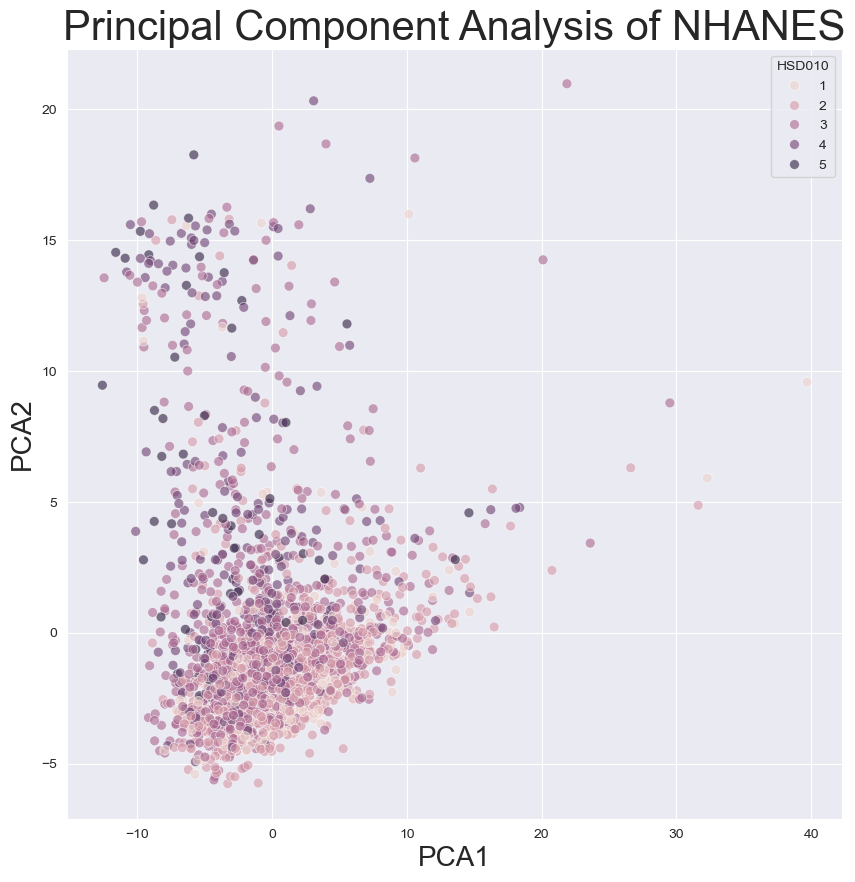

In [24]:
# load library 
# ----------
from sklearn.decomposition import PCA

# apply PCA
# ----------
pca = PCA(n_components=2)
principalComponents_nhanes = pca.fit_transform(X)

# convert into a dataframe
# ----------
pca_df = pd.DataFrame(data = principalComponents_nhanes, 
                      columns = ['principal component 1', 
                                 'principal component 2'])
# view factor loadings as dataframe
pca_df.head()

# plot
# ---------- 
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.set_xlabel('PCA1',fontsize=20)
ax.set_ylabel('PCA2',fontsize=20)
ax.set_title("Principal Component Analysis of NHANES",fontsize=30)
plotting_df  = pd.concat([pca_df, hsd010], axis=1)
sns.scatterplot(x=plotting_df['principal component 1'],
                y=plotting_df['principal component 2'],
                hue=plotting_df['HSD010'],
                ax=ax,
                s=50,
                alpha=.6);
plt.show()

Explanation of plot: This plot shows PC1 (x-axis) which captures the largest source of variation across the variables, and PC2 (y-axis) which captures the second-largest source of variation. This graph demonstrates that there is a lot of overlap in groups, exemplifying that health status is affected by a multi-dimensional array of features. Those in "poorer" health condtions are concentrated on the left bottom corner, indicating that self-reported health status aligns with major sources of variation in the NHANES data. 

### Choose a Clustering Algorithm - Kmeans

- Choose a clustering algorithm and explain it in 1-2 sentences.
- Cluster the nhanes data. Detail any choice you need to make with regards to number of clusters, and how you arrived at that choice. For instance, you might use the [elbow method](https://en.wikipedia.org/wiki/Elbow_method_(clustering)) if you choose k-means.
- Plot your clusters on top of BMI v. Income Poverty Ratio Plot. Describe what you see in 1-2 sentences.
- Retrain the clustering algorithm, but this time use your PCA results instead of the original dataframe. Plot the clusters on top of the 2D PCA scatterplot from the previous step. Describe your results in 1-2 sentences.

K-Means clustering partitions the dataset so that groups that are similar are closer to one another and distance between points is measured. The workflow (ChatGPT helped) is: 

1. Choose the number of clusters (K) 

2. Initialize K centroids (randomly select points or use smart initialization)

3. Assign each data point to the nearest centroid to form the K clusters

4. Recalculate the centroids as the mean of all points in each cluster

5. Repeat steps 3–4 until the assignments cconvergence

The goal is to maximize within-cluster similarity is maximized and minimize the between-cluster similarity.

### Cluster nhanes

In [42]:
# load libraries 
# ----------
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# settings
%matplotlib inline

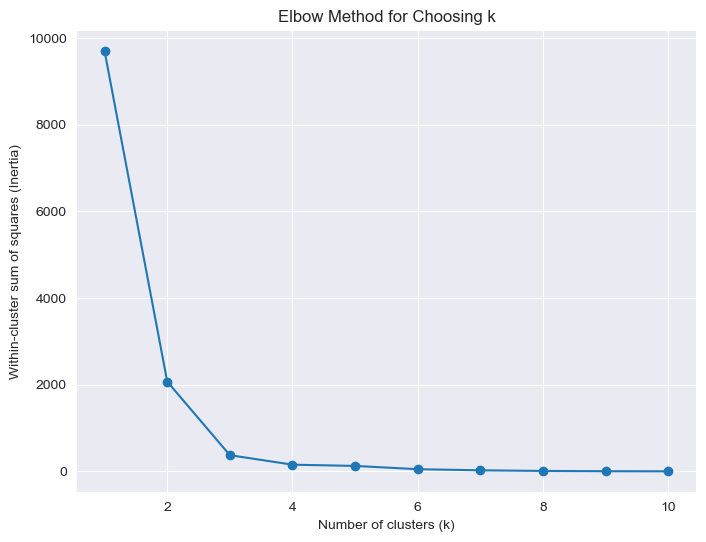

In [44]:
# using elbow method to see the best number of features 
# create an array of points
X = np.array([[0,1], [1,2], [1, 0], [-1, -3],
             [15, 21], [18, 30], [20, 20], [22, 19],
             [45, 50], [42, 48], [60, 40], [50, 50]])
X

# range of k values to try
k_values = range(1, 11)

inertia = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# plot elbow curve
plt.figure(figsize=(8,6))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-cluster sum of squares (Inertia)')
plt.title('Elbow Method for Choosing k')
plt.show()


based on the inertia (looking at y-axis), we see that the cutoff is at 3 clusters so we will use 3 clusters.

### Plot your clusters on top of the BMI v. Income Poverty Ratio Plot

Centers
[[-0.81996138 -0.47447399]
 [ 1.04225435 -0.30919995]
 [-0.35949009  1.46802557]]

Labels
[1 0 0 ... 2 1 1]

Coordinates: [0 1] Label: 1
Coordinates: [1 2] Label: 0
Coordinates: [1 0] Label: 0
Coordinates: [-1 -3] Label: 1
Coordinates: [15 21] Label: 1
Coordinates: [18 30] Label: 0
Coordinates: [20 20] Label: 2
Coordinates: [22 19] Label: 1
Coordinates: [45 50] Label: 1
Coordinates: [42 48] Label: 1
Coordinates: [60 40] Label: 2
Coordinates: [50 50] Label: 0


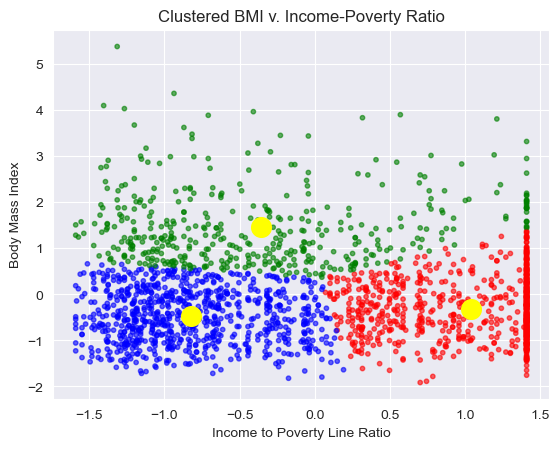

In [33]:
# first, running the kmeans cluster model using k=3 because the elbow method above illustrated that around 3 clusters we see the inertia dropoff.

nhanes_scaled_pred = nhanes_scaled 

# set random seed
np.random.seed(10)

# specify kmeans algorithm - using 3 clusters
# ----------
kmeans = KMeans(n_clusters=3,
                n_init=10,
                max_iter=300 #default
                ).fit(X)


nhanes_scaled_pred['cluster'] = kmeans.fit_predict(nhanes_scaled[['INDFMPIR', 'BMXBMI']])


# print the centers 
print("Centers")
print(kmeans.cluster_centers_)
print()

# print labels
print("Labels")
print(kmeans.labels_)
print()

# print coordinates and labels 
for point, label in zip(X, kmeans.labels_):
    print("Coordinates:", point, "Label:", label)
    
# get centroids
centroids = kmeans.cluster_centers_
cen_x = [i[0] for i in centroids] 
cen_y = [i[1] for i in centroids]

## add to df
nhanes_scaled_pred['cen_x'] = nhanes_scaled_pred.cluster.map({0:cen_x[0], 1:cen_x[1], 2:cen_x[2]})
nhanes_scaled_pred['cen_y'] = nhanes_scaled_pred.cluster.map({0:cen_y[0], 1:cen_y[1], 2:cen_y[2]})
# define and map colors
colors = ['blue', 'red', 'green']
nhanes_scaled_pred['c'] = nhanes_scaled_pred.cluster.map({0:colors[0], 1:colors[1], 2:colors[2]})

# plotting the k means clusters against the BMI and income-poverty ratio 
plt.title("Clustered BMI v. Income-Poverty Ratio")
plt.xlabel("Income to Poverty Line Ratio")
plt.ylabel("Body Mass Index")
plt.scatter(nhanes_scaled_pred.INDFMPIR, nhanes_scaled_pred.BMXBMI, c=nhanes_scaled_pred.c, alpha = 0.6, s=10)
plt.scatter(kmeans.cluster_centers_[:, 0], 
            kmeans.cluster_centers_[:, 1], 
            s=200,                             # Set centroid size
            c='yellow')                           # Set centroid color
plt.show()

The plot has the following elements:
each dot is one NHANES respondent; the x-axis is the standardized income:poverty ratio; the y-axis is a standardized BMI that increases in scale as the values get higher. The green, blue, and red colors correspond to a cluster that the kmeans algorithm created, and the yellow centroids are the "average" person in each cluster. There are 3 clusters because we initialized the algorithm that way after using the elbow method to determine that around 3 clusters, there is marginally no more added benefit to having another cluster.

We see a lot more horizontal spread than vertical spread in this graph, showing that income:poverty is responsible for more of the reasons for clustering individuals. 

Cluster 1(blue): There is a large group of people whose income and BMI profiles are both below average.
Cluster 2(green): Another group has a higher BMI value with income around the mean. This is signalling that there is some heterogeneity among BMI from just socioeconomic conditions.
Cluster 3 (red): this group has a higher income and lower BMI which corroborates a lot of public health conceptions: people with more resources that income can create (food/nutrition, medical/preventative care, less stress) can have higher health outcomes.

### Retrain the clustering algorithm on PCA components and plot clusters on your 2D scatter

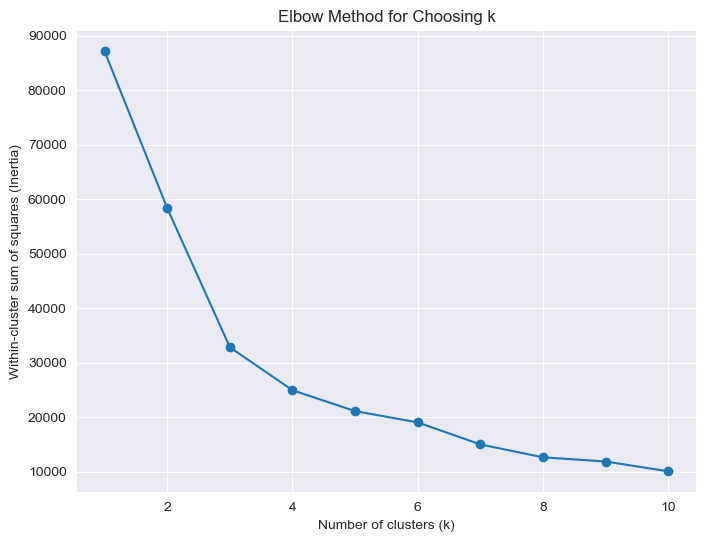

In [108]:
# train the k-means clustering algorithm again, using the elbow method to select optimal number of clusters 

#  pca_df_pred = pca_df (laodings)

# using pca dataframe that is "loadings" since I made a column that tells us what the PCAs are 
pca_pred_df = loadings

# using elbow method to see the best number of features 
# create an array of points

# range of k values to try
k_values = range(1, 11)

inertia = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_pred_df)
    inertia.append(kmeans.inertia_)

# plot elbow curve
plt.figure(figsize=(8,6))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-cluster sum of squares (Inertia)')
plt.title('Elbow Method for Choosing k')
plt.show()

# will use 3 clusters again

In [90]:
# running kmeans algorithm:


np.random.seed(10)

kmeans = KMeans(
    n_clusters=3,
    n_init=10,
    max_iter=300,
    random_state=10
)

# cluster VARIABLES (rows of loadings)
pca_pred_df['cluster'] = kmeans.fit_predict(
    pca_pred_df.iloc[:, :2]   # PC1 & PC2 loadings
)

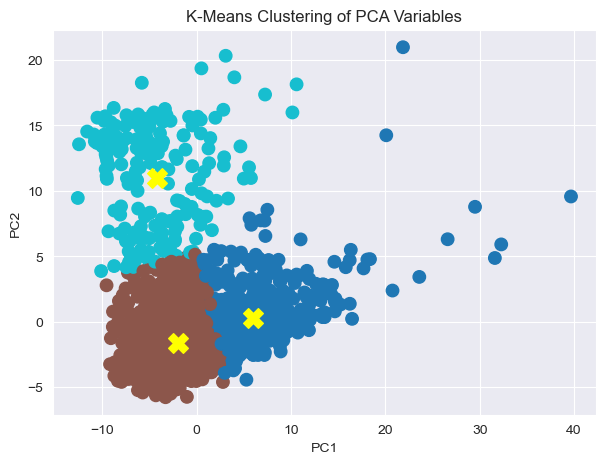

In [100]:
# plot variable clusters in PCA loading space
plt.figure(figsize=(7,5))

plt.scatter(
    pca_pred_df.iloc[:, 0],
    pca_pred_df.iloc[:, 1],
    c=pca_pred_df['cluster'],
    cmap='tab10',
    s=80
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c='yellow',
    s=200,
    marker='X'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering of PCA Variables")
plt.show()


In the plot above, kmeans was done on the PCA dataset. Each point represents an original variable positioned according to its contributions to the first two principal components. Variables that appear close together in this plot behave similarly in shaping the underlying structure of the data. In this plot, instead of each observation an individual (like they signaled with running with kmeans on just the nhanes_scaled dataset),  we are now looking at each observation as athe amount of contribution the nhanes_scaled dataset variable has on the first two principal components. We are getting to see an overall contribution pattern the clusters have.

## Neural Network

Now we are ready to predict! Do the following:

- Choose either HSD010 or HSD010\_binary as your target outcome.  
- Train a neural network using the original features. Much of the code to train a basic neural net has been set up for you, but you will need to fill in a couple of missing pieces.
- Train a neural network using only your PCA components as features.
- Train a neural network using your PCA components and the predicted class membership from your clustering algorithm as features.
- Compare and contrast how well each algorithm did. Which featurization technique would you pick and why?

Below we provide a template for training a neural network. Use this template for training on the original features, on the PCA components, and the PCA components + the predicted classes from your clusters.

note: I did this on d-lab server by installing tenserflow and then using keras

### Neural Network on Original Features

In [115]:
hsd010

0       1
1       1
2       2
3       2
4       3
       ..
2059    3
2060    2
2061    4
2062    1
2063    2
Name: HSD010, Length: 2064, dtype: int64

In [2]:
# partition data
# -----------
y = hsd010 # either hsd010 or hsd010_binary, may need to convert to numeric if it isn't already 
X = nhanes_scaled # drop out any columns that aren't features

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size = .25, 
                                                    random_state = 10)

print(f'The dataset contains {len(X_train)} training data samples, and {len(X_test)} test data samples')

NameError: name 'hsd010' is not defined

In [ ]:
# load libraries
# -----------
import keras
from keras.utils import to_categorical

num_classes = len(set(y_train)) # using 5 because y_train has 5 categorical values for hsd010
# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
num_classes = y_test.shape[1]

In [3]:
num_classes = len(set(y_train))
num_classes

NameError: name 'y_train' is not defined

In [ ]:
print(y_train.shape)
print(y_test.shape)


In [ ]:
# load libraries
# -----------
import keras
from keras.utils import to_categorical
# to handle non-zero start, the y_train and y_test dataset are starting at -1 position

y_train = y_train - 1
y_test = y_test - 1
num_classes = len(set(y_train)) # using 5 because y_train has 5 categorical values for hsd010

# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
num_classes = y_test.shape[1]

In [ ]:
# create neural network model
# -----------
model = Sequential()

model.add(Dense(X_train.shape[1], input_dim=X_train.shape[1], kernel_initializer='normal', activation='relu')
)


model.add(Dense(num_classes, kernel_initializer="normal", activation="softmax"))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


## Add any additional layers you wish here

model.compile(loss= 'categorical_crossentropy', optimizer= 'adam', metrics=['accuracy'])

model.fit(X_train, y_train, 
          validation_data=(X_test, y_test), 
          epochs=10, batch_size=200, 
          verbose=2) # like CV


ran on d-lab server with following scores:


Epoch 1/10
/srv/conda/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
8/8 - 1s - 128ms/step - accuracy: 0.3986 - loss: 1.4239 - val_accuracy: 0.4360 - val_loss: 1.3146
Epoch 2/10
8/8 - 0s - 12ms/step - accuracy: 0.5071 - loss: 1.2005 - val_accuracy: 0.4419 - val_loss: 1.2526
Epoch 3/10
8/8 - 0s - 13ms/step - accuracy: 0.5491 - loss: 1.0971 - val_accuracy: 0.4438 - val_loss: 1.2108
Epoch 4/10
8/8 - 0s - 12ms/step - accuracy: 0.6008 - loss: 1.0131 - val_accuracy: 0.4671 - val_loss: 1.1805
Epoch 5/10
8/8 - 0s - 12ms/step - accuracy: 0.6363 - loss: 0.9404 - val_accuracy: 0.4864 - val_loss: 1.1630
Epoch 6/10
8/8 - 0s - 13ms/step - accuracy: 0.6770 - loss: 0.8750 - val_accuracy: 0.4961 - val_loss: 1.1495
Epoch 7/10
8/8 - 0s - 12ms/step - accuracy: 0.7080 - loss: 0.8123 - val_accuracy: 0.5058 - val_loss: 1.1375
Epoch 8/10
8/8 - 0s - 13ms/step - accuracy: 0.7410 - loss: 0.7530 - val_accuracy: 0.5039 - val_loss: 1.1270
Epoch 9/10
8/8 - 0s - 13ms/step - accuracy: 0.7623 - loss: 0.6991 - val_accuracy: 0.5252 - val_loss: 1.1185
Epoch 10/10
8/8 - 0s - 12ms/step - accuracy: 0.8068 - loss: 0.6450 - val_accuracy: 0.5271 - val_loss: 1.1140
<keras.src.callbacks.history.History at 0x7d1a2c5b9d10>

### Neural Network on Principal Components

In [ ]:
import keras
from keras.utils import to_categorical
X_train, X_test, y_train, y_test = train_test_split(pca_df.values, y, test_size = .25, random_state = 10)

num_classes = len(np.unique(y)) + 1
# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
num_classes = y_test.shape[1]

model = Sequential()

model.add(
    Dense(X_train.shape[1], input_dim=X_train.shape[1], kernel_initializer='normal', activation='relu')
)
model.add(
    Dense(num_classes, kernel_initializer="normal", activation="softmax")
)

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy')

model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=100, verbose=2)

dlab server output:


Epoch 1/30
16/16 - 1s - loss: 1.7563 - accuracy: 0.2694 - auc: 0.6424 - val_loss: 1.7035 - val_accuracy: 0.4128 - val_auc: 0.7648 - 1s/epoch - 78ms/step
Epoch 2/30
16/16 - 0s - loss: 1.6525 - accuracy: 0.4302 - auc: 0.7934 - val_loss: 1.6059 - val_accuracy: 0.4574 - val_auc: 0.8031 - 56ms/epoch - 4ms/step
Epoch 3/30
16/16 - 0s - loss: 1.5518 - accuracy: 0.4587 - auc: 0.8141 - val_loss: 1.5088 - val_accuracy: 0.4496 - val_auc: 0.8141 - 57ms/epoch - 4ms/step
Epoch 4/30
16/16 - 0s - loss: 1.4530 - accuracy: 0.4742 - auc: 0.8217 - val_loss: 1.4203 - val_accuracy: 0.4496 - val_auc: 0.8212 - 48ms/epoch - 3ms/step
Epoch 5/30
16/16 - 0s - loss: 1.3681 - accuracy: 0.4910 - auc: 0.8300 - val_loss: 1.3489 - val_accuracy: 0.4612 - val_auc: 0.8283 - 48ms/epoch - 3ms/step
Epoch 6/30
16/16 - 0s - loss: 1.3010 - accuracy: 0.5000 - auc: 0.8394 - val_loss: 1.2961 - val_accuracy: 0.4690 - val_auc: 0.8356 - 55ms/epoch - 3ms/step
Epoch 7/30
16/16 - 0s - loss: 1.2515 - accuracy: 0.5006 - auc: 0.8473 - val_loss: 1.2587 - val_accuracy: 0.4729 - val_auc: 0.8413 - 46ms/epoch - 3ms/step
Epoch 8/30
16/16 - 0s - loss: 1.2130 - accuracy: 0.5045 - auc: 0.8543 - val_loss: 1.2298 - val_accuracy: 0.4845 - val_auc: 0.8461 - 42ms/epoch - 3ms/step
Epoch 9/30
16/16 - 0s - loss: 1.1822 - accuracy: 0.5058 - auc: 0.8603 - val_loss: 1.2091 - val_accuracy: 0.4922 - val_auc: 0.8499 - 43ms/epoch - 3ms/step
Epoch 10/30
16/16 - 0s - loss: 1.1581 - accuracy: 0.5149 - auc: 0.8646 - val_loss: 1.1901 - val_accuracy: 0.4903 - val_auc: 0.8534 - 49ms/epoch - 3ms/step
Epoch 11/30
16/16 - 0s - loss: 1.1374 - accuracy: 0.5245 - auc: 0.8684 - val_loss: 1.1755 - val_accuracy: 0.4942 - val_auc: 0.8562 - 41ms/epoch - 3ms/step
Epoch 12/30
16/16 - 0s - loss: 1.1195 - accuracy: 0.5297 - auc: 0.8725 - val_loss: 1.1641 - val_accuracy: 0.5000 - val_auc: 0.8583 - 39ms/epoch - 2ms/step
Epoch 13/30
16/16 - 0s - loss: 1.1039 - accuracy: 0.5349 - auc: 0.8754 - val_loss: 1.1543 - val_accuracy: 0.4922 - val_auc: 0.8598 - 38ms/epoch - 2ms/step
Epoch 14/30
16/16 - 0s - loss: 1.0899 - accuracy: 0.5388 - auc: 0.8781 - val_loss: 1.1467 - val_accuracy: 0.4922 - val_auc: 0.8610 - 38ms/epoch - 2ms/step
Epoch 15/30
16/16 - 0s - loss: 1.0772 - accuracy: 0.5401 - auc: 0.8810 - val_loss: 1.1377 - val_accuracy: 0.4922 - val_auc: 0.8629 - 35ms/epoch - 2ms/step
Epoch 16/30
16/16 - 0s - loss: 1.0657 - accuracy: 0.5426 - auc: 0.8831 - val_loss: 1.1324 - val_accuracy: 0.4981 - val_auc: 0.8635 - 39ms/epoch - 2ms/step
Epoch 17/30
16/16 - 0s - loss: 1.0557 - accuracy: 0.5459 - auc: 0.8852 - val_loss: 1.1271 - val_accuracy: 0.5097 - val_auc: 0.8643 - 37ms/epoch - 2ms/step
Epoch 18/30
16/16 - 0s - loss: 1.0463 - accuracy: 0.5510 - auc: 0.8867 - val_loss: 1.1237 - val_accuracy: 0.5039 - val_auc: 0.8646 - 38ms/epoch - 2ms/step
Epoch 19/30
16/16 - 0s - loss: 1.0373 - accuracy: 0.5543 - auc: 0.8887 - val_loss: 1.1199 - val_accuracy: 0.4942 - val_auc: 0.8648 - 37ms/epoch - 2ms/step
Epoch 20/30
16/16 - 0s - loss: 1.0303 - accuracy: 0.5594 - auc: 0.8902 - val_loss: 1.1164 - val_accuracy: 0.4961 - val_auc: 0.8655 - 37ms/epoch - 2ms/step
Epoch 21/30
16/16 - 0s - loss: 1.0221 - accuracy: 0.5633 - auc: 0.8920 - val_loss: 1.1121 - val_accuracy: 0.5039 - val_auc: 0.8662 - 41ms/epoch - 3ms/step
Epoch 22/30
16/16 - 0s - loss: 1.0146 - accuracy: 0.5652 - auc: 0.8935 - val_loss: 1.1109 - val_accuracy: 0.5000 - val_auc: 0.8662 - 39ms/epoch - 2ms/step
Epoch 23/30
16/16 - 0s - loss: 1.0080 - accuracy: 0.5743 - auc: 0.8950 - val_loss: 1.1090 - val_accuracy: 0.5039 - val_auc: 0.8664 - 39ms/epoch - 2ms/step
Epoch 24/30
16/16 - 0s - loss: 1.0014 - accuracy: 0.5743 - auc: 0.8965 - val_loss: 1.1105 - val_accuracy: 0.5000 - val_auc: 0.8656 - 41ms/epoch - 3ms/step
Epoch 25/30
16/16 - 0s - loss: 0.9955 - accuracy: 0.5782 - auc: 0.8972 - val_loss: 1.1088 - val_accuracy: 0.4981 - val_auc: 0.8662 - 38ms/epoch - 2ms/step
Epoch 26/30
16/16 - 0s - loss: 0.9918 - accuracy: 0.5801 - auc: 0.8979 - val_loss: 1.1075 - val_accuracy: 0.4922 - val_auc: 0.8661 - 38ms/epoch - 2ms/step
Epoch 27/30
16/16 - 0s - loss: 0.9853 - accuracy: 0.5833 - auc: 0.8992 - val_loss: 1.1086 - val_accuracy: 0.4922 - val_auc: 0.8659 - 40ms/epoch - 3ms/step
Epoch 28/30
16/16 - 0s - loss: 0.9797 - accuracy: 0.5840 - auc: 0.9005 - val_loss: 1.1053 - val_accuracy: 0.4884 - val_auc: 0.8663 - 36ms/epoch - 2ms/step
Epoch 29/30
16/16 - 0s - loss: 0.9752 - accuracy: 0.5937 - auc: 0.9019 - val_loss: 1.1050 - val_accuracy: 0.4922 - val_auc: 0.8663 - 38ms/epoch - 2ms/step
Epoch 30/30
16/16 - 0s - loss: 0.9707 - accuracy: 0.5879 - auc: 0.9025 - val_loss: 1.1050 - val_accuracy: 0.4884 - val_auc: 0.8664 - 40ms/epoch - 3ms/step
<keras.callbacks.History at 0x7fd595586b80>

### Neural Network on Principal Components + Cluster Membership

In [ ]:
y = hsd010.values
# reran all the needed code in d-lab server to make this run

nhanes_scaled_pred_neural = nhanes_scaled_pred['cluster'].reset_index(drop=True)

pca_cluster = pd.concat([pca_df, nhanes_scaled_pred_neural], axis=1)

X_train, X_test, y_train, y_test = train_test_split(pca_cluster.values, y, test_size = .25, random_state = 10)

num_classes = len(np.unique(y)) + 1
# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
num_classes = y_test.shape[1]

model = Sequential()

model.add(
    Dense(X_train.shape[1], input_dim=X_train.shape[1], kernel_initializer='normal', activation='relu')
)
model.add(
    Dense(num_classes, kernel_initializer="normal", activation="softmax")
)

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=100, verbose=2)

dlab server output:

Epoch 1/30
/srv/conda/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
16/16 - 1s - 58ms/step - accuracy: 0.2403 - loss: 1.7661 - val_accuracy: 0.3934 - val_loss: 1.7189
Epoch 2/30
16/16 - 0s - 7ms/step - accuracy: 0.4393 - loss: 1.6797 - val_accuracy: 0.4244 - val_loss: 1.6330
Epoch 3/30
16/16 - 0s - 7ms/step - accuracy: 0.4619 - loss: 1.5940 - val_accuracy: 0.4341 - val_loss: 1.5455
Epoch 4/30
16/16 - 0s - 7ms/step - accuracy: 0.4813 - loss: 1.5040 - val_accuracy: 0.4380 - val_loss: 1.4564
Epoch 5/30
16/16 - 0s - 7ms/step - accuracy: 0.4890 - loss: 1.4149 - val_accuracy: 0.4516 - val_loss: 1.3774
Epoch 6/30
16/16 - 0s - 7ms/step - accuracy: 0.4955 - loss: 1.3367 - val_accuracy: 0.4651 - val_loss: 1.3140
Epoch 7/30
16/16 - 0s - 7ms/step - accuracy: 0.4981 - loss: 1.2737 - val_accuracy: 0.4574 - val_loss: 1.2648
Epoch 8/30
16/16 - 0s - 7ms/step - accuracy: 0.5058 - loss: 1.2247 - val_accuracy: 0.4690 - val_loss: 1.2284
Epoch 9/30
16/16 - 0s - 7ms/step - accuracy: 0.5142 - loss: 1.1877 - val_accuracy: 0.4632 - val_loss: 1.2019
Epoch 10/30
16/16 - 0s - 7ms/step - accuracy: 0.5245 - loss: 1.1577 - val_accuracy: 0.4671 - val_loss: 1.1835
Epoch 11/30
16/16 - 0s - 7ms/step - accuracy: 0.5323 - loss: 1.1346 - val_accuracy: 0.4787 - val_loss: 1.1693
Epoch 12/30
16/16 - 0s - 7ms/step - accuracy: 0.5381 - loss: 1.1156 - val_accuracy: 0.4864 - val_loss: 1.1584
Epoch 13/30
16/16 - 0s - 7ms/step - accuracy: 0.5472 - loss: 1.0995 - val_accuracy: 0.4961 - val_loss: 1.1489
Epoch 14/30
16/16 - 0s - 7ms/step - accuracy: 0.5472 - loss: 1.0857 - val_accuracy: 0.5019 - val_loss: 1.1426
Epoch 15/30
16/16 - 0s - 7ms/step - accuracy: 0.5517 - loss: 1.0740 - val_accuracy: 0.5039 - val_loss: 1.1345
Epoch 16/30
16/16 - 0s - 7ms/step - accuracy: 0.5581 - loss: 1.0631 - val_accuracy: 0.5058 - val_loss: 1.1290
Epoch 17/30
16/16 - 0s - 7ms/step - accuracy: 0.5568 - loss: 1.0532 - val_accuracy: 0.5019 - val_loss: 1.1243
Epoch 18/30
16/16 - 0s - 8ms/step - accuracy: 0.5640 - loss: 1.0446 - val_accuracy: 0.4961 - val_loss: 1.1202
Epoch 19/30
16/16 - 0s - 7ms/step - accuracy: 0.5640 - loss: 1.0369 - val_accuracy: 0.5000 - val_loss: 1.1173
Epoch 20/30
16/16 - 0s - 7ms/step - accuracy: 0.5665 - loss: 1.0304 - val_accuracy: 0.4981 - val_loss: 1.1141
Epoch 21/30
16/16 - 0s - 7ms/step - accuracy: 0.5698 - loss: 1.0238 - val_accuracy: 0.5000 - val_loss: 1.1135
Epoch 22/30
16/16 - 0s - 7ms/step - accuracy: 0.5652 - loss: 1.0184 - val_accuracy: 0.5019 - val_loss: 1.1105
Epoch 23/30
16/16 - 0s - 7ms/step - accuracy: 0.5672 - loss: 1.0135 - val_accuracy: 0.4903 - val_loss: 1.1088
Epoch 24/30
16/16 - 0s - 7ms/step - accuracy: 0.5685 - loss: 1.0082 - val_accuracy: 0.4942 - val_loss: 1.1085
Epoch 25/30
16/16 - 0s - 7ms/step - accuracy: 0.5724 - loss: 1.0031 - val_accuracy: 0.4903 - val_loss: 1.1070
Epoch 26/30
16/16 - 0s - 7ms/step - accuracy: 0.5717 - loss: 0.9988 - val_accuracy: 0.4922 - val_loss: 1.1068
Epoch 27/30
16/16 - 0s - 7ms/step - accuracy: 0.5762 - loss: 0.9938 - val_accuracy: 0.4864 - val_loss: 1.1049
Epoch 28/30
16/16 - 0s - 7ms/step - accuracy: 0.5775 - loss: 0.9903 - val_accuracy: 0.4884 - val_loss: 1.1049
Epoch 29/30
16/16 - 0s - 7ms/step - accuracy: 0.5756 - loss: 0.9861 - val_accuracy: 0.4922 - val_loss: 1.1045
Epoch 30/30
16/16 - 0s - 7ms/step - accuracy: 0.5807 - loss: 0.9827 - val_accuracy: 0.4922 - val_loss: 1.1046
<keras.src.callbacks.history.History at 0x7d19c664edd0>

## Discussion Questions

1. In your own words, what is the difference between PCA and clustering?

 PCA is used to reduce the dimensionality in big datasets, and creates fewer uncorrelated components of all the features. This finds the data elements that capture the most variance and lets us understand which features are most importance. However, clustering creates groups among similar datapoints and focuses on proximity/similarity so that we can find patterns and see hidden data structures. We usually do this after we run a PCA analysis.

2. Did you notice any advantages to combining PCA and clustering? If so, what do you think they were? If not, why do you think you didn't see any gains from this combination?

In the neural prediction, combining PCA and clustering resulted in a slightly higher accuracy than just the PCA analysis alone, but the effect was slight. However, having the neural networks run on the PCA / PCA+cluster analysis had lower rates of accuracy. This shows that using pca or clustering can have model performing benefits. But, since I didn't see much higher accuracy rates in the combination, I think it's because the sample size is still relatively small compared to big datasets (probably for time sakes for this project), or because the PCA is a linear function and the neural networks can learn non-linear relatonships. This could lead to a different model being better suited for this type of dataset (such as trees).

## Your Answer Here

3. How can unsupervised techniques help with downstream supervised learning tasks when working with "big data?"

Unsupervised techniques can reduce the dimensionality of "big data" so that running more computationally expensive supervised models like neural networks can be done more  efficiently. It also helps with interpetability of the project and explains descriptive ideas to non-technical audiences well.